# Stage 1: Single Agent (Tools and Tool Schema)




## Install dependencies
Run this once in a fresh environment.


In [1]:
# %pip -q install langgraph langchain-openai python-dotenv
# %pip install -U ddgs

## 1) Imports

In [2]:
import os
from dotenv import load_dotenv
from typing import Any, Dict, Literal
from typing import TypedDict, Annotated, List
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

c:\Users\chunh\Documents\2606_mobile-class\2-YK_sample_code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load environment variables - please read instructions carefully

In [3]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [4]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) System prompt

In [5]:
SYSTEM = """You are a travel planning agent.

Rules:
- Ask clarifying questions only when essential info is missing.
- Do not invent facts. Use search tool for fresh facts when needed.
- When user asks "total cost", ALWAYS call estimate_trip_cost with the latest trip parameters from conversation.
- If user says "add additional one day trip", interpret as +1 day unless they explicitly say it replaces an existing day.


Output format:
1) Day-by-day plan (brief)
2) Total cost (with assumptions)
"""


## 4) Tool - estimate trip cost

In [6]:
@tool
def estimate_trip_cost(
    destination: str,
    days: int,
    travelers: int,
    #comfort: str = "mid", #this is the wrong demo
    comfort: Literal["budget", "mid", "premium"] = "mid"
) -> Dict[str, Any]:
    """
    Estimate a rough trip budget (SGD) using simple heuristics.
    comfort: budget | mid | premium
    Returns a breakdown and total estimate in SGD.
    """
    if days <= 0 or travelers <= 0:
        raise ValueError("days and travelers must be > 0")

    comfort = comfort.lower().strip()
    if comfort not in {"budget", "mid", "premium"}:
        raise ValueError("comfort must be one of: budget, mid, premium")

    # Very rough per-person-per-day estimates (SGD) excluding flights
    lodging_pppd = {"budget": 60, "mid": 140, "premium": 300}[comfort]
    food_pppd = {"budget": 30, "mid": 60, "premium": 120}[comfort]
    local_transport_pppd = {"budget": 10, "mid": 20, "premium": 50}[comfort]
    activities_pppd = {"budget": 20, "mid": 50, "premium": 120}[comfort]

    lodging = lodging_pppd * travelers * days
    food = food_pppd * travelers * days
    transport = local_transport_pppd * travelers * days
    activities = activities_pppd * travelers * days

    subtotal = lodging + food + transport + activities
    contingency = round(subtotal * 0.12)  # 12% buffer
    total = subtotal + contingency

    return {
        "destination": destination,
        "days": days,
        "travelers": travelers,
        "comfort": comfort,
        "currency": "SGD",
        "breakdown": {
            "lodging": lodging,
            "food": food,
            "local_transport": transport,
            "activities": activities,
            "contingency": contingency,
        },
        "total_estimate": total,
        "note": "Heuristic estimate excludes international flights/insurance/visa fees.",
    }

## helper function - Pretty Print

In [7]:
def pretty_print(response):
    last_msg = response["messages"][-1]

    if isinstance(last_msg.content, list):
        text = "".join(
            block["text"]
            for block in last_msg.content
            if block.get("type") == "text"
        )
    else:
        text = last_msg.content

    print(text)

## 5) Build the LangGraph agent loop

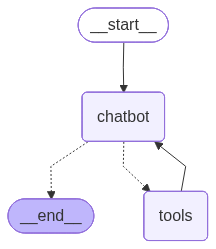

In [12]:
from langchain_community.tools import DuckDuckGoSearchRun

class State(TypedDict):
    # add_messages makes state["messages"] append-only and compatible with tool loops
    messages: Annotated[List[AnyMessage], add_messages]


tools = [estimate_trip_cost]
# web_tool = {"type": "web_search_preview"}  # LangChain docs use web_search_preview
# llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
#for ollama, web_tool needs to be changed
web_tool = DuckDuckGoSearchRun() 
tools = [estimate_trip_cost, web_tool]

llm = ChatOpenAI(
    model="qwen3", 
    temperature=0,
    openai_api_key="ollama",
    openai_api_base="http://localhost:11434/v1"
)

llm_with_tools = llm.bind_tools(tools)
def chatbot(state: State):
    # The LLM sees prior messages for this thread via checkpointer
    # We do NOT hardcode tool list in SYSTEM; tool schemas are in bind_tools.
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)  # routes to "tools" when tool calls exist
builder.add_edge("tools", "chatbot")  # tool result goes back to model for next step, this line shall be uncommented for the program to work

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 4) Run

In [13]:
msg = "Plan a 2-day Tokyo trip for 2 adults. Mid comfort. We like food and anime. Avoid very packed schedules."
resp = graph.invoke(
    {"messages": [
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": msg},
    ]},
)
pretty_print(resp)

1) **Day-by-day plan (brief):**  
**Day 1:**  
- Morning: Explore Akihabara (anime shops, maid cafes, Gundam statue).  
- Afternoon: Stroll through Ueno Park (relaxation + visit Ueno Zoo/Art Museum).  
- Evening: Food tour in Shimokitazawa (indie ramen, izakayas, and anime-themed eateries).  

**Day 2:**  
- Morning: Visit Asakusa (Senso-ji Temple) and nearby traditional markets.  
- Afternoon: Leisurely walk along the Sumida River with views of Tokyo Skytree.  
- Evening: Dine at a ryokan (traditional inn) with kaiseki cuisine.  

2) **Total cost (assumptions):**  
- **SGD 1,210** (mid-comfort estimate):  
  - Lodging: 2 nights in a mid-range hotel (~SGD 280/night).  
  - Food: 240 SGD (SGD 120/day for meals + snacks).  
  - Transport: 80 SGD (Suica/Pasmo cards + local transit).  
  - Activities: 200 SGD (anime museum entry, park admission, etc.).  
  - Contingency: 130 SGD (flexible for dining upgrades or delays).  

**Notes:**  
- Avoid peak hours (e.g., 7-9 AM/5-7 PM) for attractio

## Tool Schema

- in day 1 example, without framework, developer needs to write the tool schema below.
- with @tool, langchain automatically generate the tool schema.

In [ ]:
# tools = [
#     {
#         "type": "function",
#         "function": {
#             "name": "estimate_trip_cost",
#             "description": "Estimate a rough trip budget (SGD) using simple heuristics. comfort: budget | mid | premium. Returns a breakdown and total estimate in SGD.",
#             "parameters": {
#                 "type": "object",
#                 "properties": {
#                     "days": {
#                         "type": "integer",
#                         "description": "Number of travel days"
#                     },
#                     "travelers": {
#                         "type": "integer",
#                         "description": "Number of travelers"
#                     },
#                     "comfort": {
#                         "type": "string",
#                         "description": "Travel comfort level",
#                         "enum": ["budget", "mid", "premium"],
#                         "default": "mid"
#                     }
#                 },
#                 "required": ["days", "travelers"]
#             }
#         }
#     }
# ]

In [14]:
from langchain_core.utils.function_calling import convert_to_openai_tool

tool_schema = convert_to_openai_tool(
    estimate_trip_cost
)

from pprint import pprint
pprint(tool_schema)

{'function': {'description': 'Estimate a rough trip budget (SGD) using simple '
                             'heuristics.\n'
                             'comfort: budget | mid | premium\n'
                             'Returns a breakdown and total estimate in SGD.',
              'name': 'estimate_trip_cost',
              'parameters': {'properties': {'comfort': {'default': 'mid',
                                                        'enum': ['budget',
                                                                 'mid',
                                                                 'premium'],
                                                        'type': 'string'},
                                            'days': {'type': 'integer'},
                                            'destination': {'type': 'string'},
                                            'travelers': {'type': 'integer'}},
                             'required': ['destination', 'days', 'travelers'],
    

In [ ]:
{'function': {'description': 'Estimate a rough trip budget (SGD) using simple '
                             'heuristics.\n'
                             'comfort: budget | mid | premium\n'
                             'Returns a breakdown and total estimate in SGD.',
              'name': 'estimate_trip_cost',
              'parameters': {'properties': {'comfort': {'default': 'mid',
                                                        'enum': ['budget',
                                                                 'mid',
                                                                 'premium'],
                                                        'type': 'string'},
                                            'days': {'type': 'integer'},
                                            'destination': {'type': 'string'},
                                            'travelers': {'type': 'integer'}},
                             'required': ['destination', 'days', 'travelers'],
                             'type': 'object'}},
 'type': 'function'}